Replacing the LoRA ViT head with a Dense → ReLU → Softmax head

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------
# Device and Seed
# ---------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device: cpu


In [3]:
# ---------------------------
# Dataset Setup
# ---------------------------
DATASET_DIR = 'dataset'
IMG_SIZE = 224
FEATURE_CSV_DIR = '.'

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print('Classes:', CLASS_NAMES)

image_paths = []
labels = []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    for p in imgs:
        image_paths.append(p)
        labels.append(lbl)

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.2, random_state=42
)

print(f'Train images: {len(X_train_paths)}  Test images: {len(X_test_paths)}')
pd.DataFrame({'path': X_test_paths, 'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_test_raw.csv'), index=False)
pd.DataFrame({'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_test.csv'), index=False)


Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train images: 3200  Test images: 800


In [4]:
# ---------------------------
# Augmentations
# ---------------------------
try:
    from torchvision.transforms import TrivialAugmentWide
    trivial = TrivialAugmentWide()
    print('TrivialAugmentWide available.')
except Exception:
    trivial = None
    print('TrivialAugmentWide not available — using fallback RandomChoice.')

train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
if trivial is not None:
    train_transforms = transforms.Compose(train_base + [trivial, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
else:
    fallback_aug = transforms.RandomChoice([
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    ])
    train_transforms = transforms.Compose(train_base + [fallback_aug, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


TrivialAugmentWide available.


In [5]:
# ---------------------------
# Feature Extractor
# ---------------------------
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

X_test_feats = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms) for p in tqdm(X_train_paths)])

pd.DataFrame(X_train_feats).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_train_features.csv'), index=False)
pd.DataFrame(X_test_feats).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_test_features.csv'), index=False)


100%|██████████| 3200/3200 [06:43<00:00,  7.92it/s]


In [6]:
# ---------------------------
# Attention-Guided Mixup
# ---------------------------
def attention_guided_mixup(X, y, mixup_count, alpha=0.4):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats)
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count=mixup_count)

X_final = X_mix
y_final = y_mix

pd.DataFrame(X_final).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_train_mixup.csv'), index=False)
pd.DataFrame({'label': y_final}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_train.csv'), index=False)


In [7]:
# ---------------------------
# Dense Head (ReLU + Softmax)
# ---------------------------
class DenseHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.fc2(self.relu(self.fc1(x))).squeeze(0)
        return self.fc2(self.relu(self.fc1(x)))

In [8]:
# ---------------------------
# PolyLoss with Label Smoothing
# ---------------------------
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=1.0, label_smoothing=0.1):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        targets_onehot = F.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = F.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

In [9]:
# ---------------------------
# SAM + Cosine LR
# ---------------------------
from sam import SAM
in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)

model_head = DenseHead(in_features=in_features, num_classes=num_classes).to(device)
criterion = Poly1LossWithSmoothing(num_classes=num_classes)
base_optimizer = torch.optim.Adam
optimizer = SAM(model_head.parameters(), base_optimizer, lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/20  Loss: 2.4855
Epoch 2/20  Loss: 2.2513
Epoch 3/20  Loss: 2.1681
Epoch 4/20  Loss: 2.0964
Epoch 5/20  Loss: 2.0364
Epoch 6/20  Loss: 1.9785
Epoch 7/20  Loss: 1.9176
Epoch 8/20  Loss: 1.8663
Epoch 9/20  Loss: 1.8143
Epoch 10/20  Loss: 1.7627
Epoch 11/20  Loss: 1.7197
Epoch 12/20  Loss: 1.6787
Epoch 13/20  Loss: 1.6434
Epoch 14/20  Loss: 1.6117
Epoch 15/20  Loss: 1.5900
Epoch 16/20  Loss: 1.5680
Epoch 17/20  Loss: 1.5524
Epoch 18/20  Loss: 1.5420
Epoch 19/20  Loss: 1.5347
Epoch 20/20  Loss: 1.5313


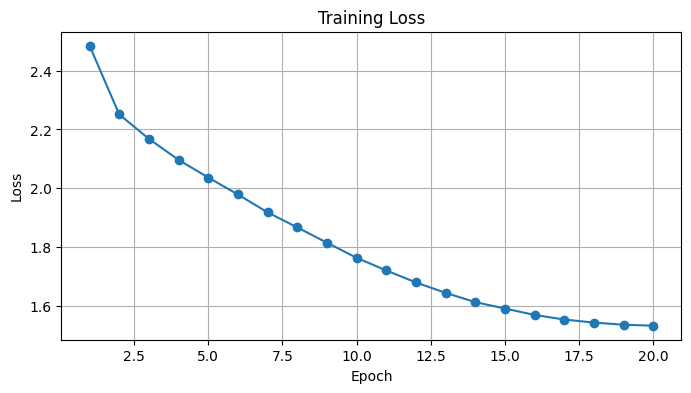

In [10]:
# ---------------------------
# Training
# ---------------------------
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32), torch.tensor(y_final, dtype=torch.long)), batch_size=batch_size, shuffle=True)

EPOCHS = 20
train_losses = []
for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        logits2 = model_head(xb)
        criterion(logits2, yb).backward()
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * xb.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    scheduler.step()
    print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {epoch_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


In [11]:
# ---------------------------
# TTA Inference
# ---------------------------
tta_transforms = [
    val_transform,
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomRotation(15), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
]

@torch.no_grad()
def tta_predict(paths, model):
    model.eval()
    all_preds = []
    for path in tqdm(paths):
        img = Image.open(path).convert('RGB')
        logits_sum = torch.zeros(num_classes, device=device)
        for tform in tta_transforms:
            x = tform(img).unsqueeze(0).to(device)   # [1,3,H,W]
            feat = feature_model(x)                  # [1,feat_dim]
            logits = model(feat)                     # [1,num_classes]
            logits_sum += logits.squeeze(0)          # [num_classes]
        all_preds.append(logits_sum.argmax().item())
    return all_preds

y_pred = tta_predict(X_test_paths, model_head)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

100%|██████████| 800/800 [09:10<00:00,  1.45it/s]

Accuracy  : 0.9725
Precision : 0.9726
Recall    : 0.9725
F1 Score  : 0.9725


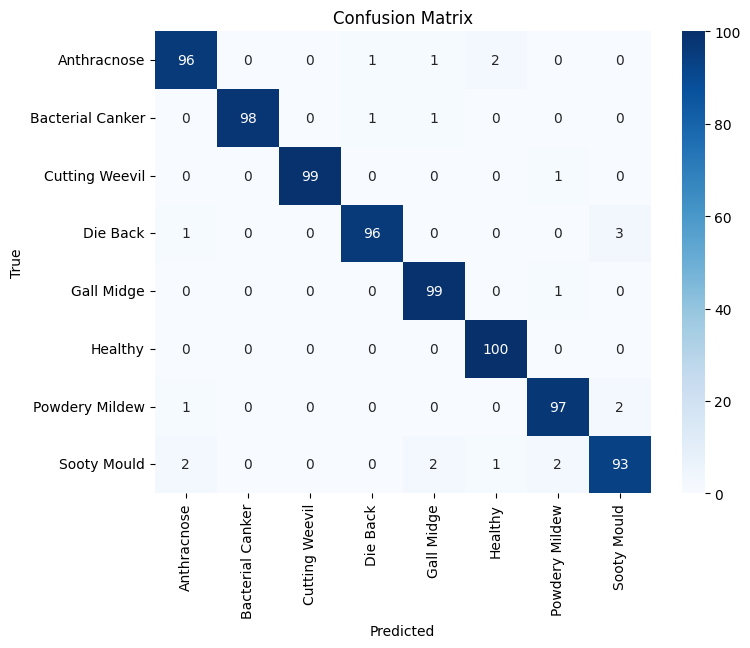

In [12]:
# ---------------------------
# Confusion Matrix
# ---------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()